# Air Quality Index (AQI) Prediction — Exploratory Data Analysis and Data Understanding


## Dataset Selection and UNSDG Alignment

For the regression task, the **Air Quality in India (city_day)** dataset from Kaggle is used.
The dataset contains daily air quality measurements across multiple Indian cities.

This dataset aligns with:
- **UNSDG 3: Good Health and Well-being**
- **UNSDG 11: Sustainable Cities and Communities**

Air pollution directly affects public health and urban sustainability. Predicting AQI helps understand pollution patterns and supports data-driven policy decisions.


### Loading the Dataset
The dataset is loaded into a pandas DataFrame for inspection and analysis.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving city_day.csv to city_day (2).csv


In [2]:
import pandas as pd

# loading the air quality dataset (city_day)
air_quality = pd.read_csv("city_day.csv")

# preview first few rows
air_quality.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


### Dataset Source

- **Created by:** Rohan Rao (Kaggle contributor)
- **Accessed from:** Kaggle — Air Quality Data in India
- **Format:** CSV (daily city-level air quality data)
- **Time Span:** Multiple years of daily observations


### Attribute Description

| Column | Description |
|------|-------------|
| City | Name of the city |
| Date | Date of observation |
| PM2.5 | Fine particulate matter concentration |
| PM10 | Coarse particulate matter concentration |
| NO | Nitric oxide |
| NO2 | Nitrogen dioxide |
| NOx | Oxides of nitrogen |
| NH3 | Ammonia |
| CO | Carbon monoxide |
| SO2 | Sulfur dioxide |
| O3 | Ozone |
| Benzene | Benzene concentration |
| Toluene | Toluene concentration |
| Xylene | Xylene concentration |
| AQI | Air Quality Index (target variable) |
| AQI_Bucket | AQI category label |


### Potential Questions the Dataset Can Answer

1. How do different pollutants contribute to changes in AQI?
2. Do certain cities consistently show higher AQI levels?
3. Which pollutants are the strongest predictors of AQI?

### Basic Inspection of the Dataset
Understanding dataset size, structure, and data types.

In [3]:
# dataset dimensions
air_quality.shape

(29531, 16)

In [4]:
# column types and missing values
air_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [5]:
# summary statistics for numerical columns
air_quality.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


### Dataset Quality Assessment
Checking completeness, missing values, and overall suitability for regression.

In [6]:
# checking missing values per column
air_quality.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


## 1. Dataset Quality and Preprocessing

### Missing Values Assessment
The air quality dataset contains a considerable number of missing values across several pollutant variables, including **PM2.5, PM10, NO, NO₂, NH₃, Benzene, Toluene, and Xylene**. However, the target variable **AQI (Air Quality Index)** is available for a large portion of the dataset.

Since AQI is the dependent variable for this regression task, rows with missing AQI values were removed to ensure that all observations used for modeling contain valid target values. This step improves the reliability of subsequent analysis and model training.

### Dataset Suitability
Despite missing values in some pollutant measurements, the dataset is suitable for regression analysis because:
- AQI values are sufficiently available after cleaning.
- The pollutant variables are directly relevant to air quality prediction.
- The dataset spans multiple cities and time periods, providing diverse and representative observations.


## Exploratory Data Analysis (EDA)

This section explores the distribution of AQI and its relationship with key pollutant variables.

In [7]:
# removing rows where target AQI is missing
air_quality_clean = air_quality.dropna(subset=['AQI'])

In [8]:
# fill missing values using median
numeric_cols = air_quality_clean.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    air_quality_clean[col] = air_quality_clean[col].fillna(
        air_quality_clean[col].median()
    )


/tmp/ipython-input-354949287.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_quality_clean[col] = air_quality_clean[col].fillna(


Missing values were imputed using the median to reduce the influence of extreme pollution values and maintain robust central tendencies

**Outlier Detection**

The AQI distribution shows a strong right skew with extreme values.  
To reduce the impact of outliers on regression performance, the IQR method was used to identify and remove extreme AQI values.


In [9]:
# IQR method for AQI
Q1 = air_quality_clean['AQI'].quantile(0.25)
Q3 = air_quality_clean['AQI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

air_quality_clean = air_quality_clean[
    (air_quality_clean['AQI'] >= lower_bound) &
    (air_quality_clean['AQI'] <= upper_bound)
]

In [10]:
air_quality_clean.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000,23492.000000
mean,60.064860,107.812502,15.770651,26.656594,29.542867,21.700389,1.388220,12.586612,34.401177,2.988180,7.005213,2.117447,143.401881
std,46.799243,66.434721,19.524220,20.615936,26.887742,22.655374,2.486927,13.386012,20.930132,15.156035,17.037842,4.039121,88.635883
min,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.560000,68.775000,5.500000,11.750000,13.550000,10.850000,0.570000,5.670000,19.467500,0.310000,1.470000,1.420000,79.000000
50%,48.160000,96.180000,9.610000,21.540000,23.680000,16.310000,0.910000,9.100000,31.250000,1.290000,3.575000,1.420000,113.000000
75%,74.562500,121.895000,17.620000,35.540000,35.470000,24.840000,1.350000,13.900000,44.990000,2.590000,6.432500,1.420000,182.000000
max,868.660000,666.720000,390.680000,241.340000,378.240000,352.890000,101.890000,186.080000,200.410000,455.030000,454.850000,170.370000,398.000000


## 2. Summary Statistics and Descriptive Analysis

Descriptive statistics were computed to understand the distribution and variability of pollutant concentrations and AQI values.

The summary statistics indicate that:
- **PM2.5 and PM10** exhibit high variability with extremely large maximum values, indicating severe pollution events.
- Gaseous pollutants such as **NO₂, SO₂, and O₃** show moderate variability.
- The **AQI** variable has a wide range, with values extending above 2000, reflecting extreme air quality conditions in some cases.

The large ranges and standard deviations suggest the presence of **outliers**, which are common in environmental datasets and represent real-world pollution spikes rather than data errors.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Visualization

### Distribution of AQI

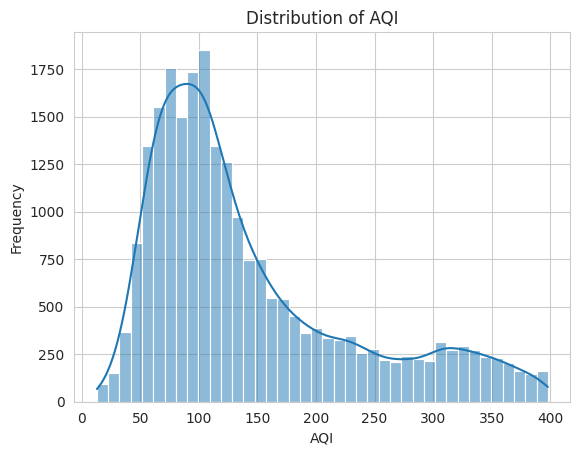

In [12]:
sns.histplot(air_quality_clean['AQI'], bins=40, kde=True)
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


## 3. Distribution of AQI

The distribution of AQI values is highly **right-skewed**, with most observations concentrated at lower AQI levels and a long tail extending toward extremely high values.

### Key Insights:
- Most observations fall within moderate to unhealthy AQI ranges.
- Extremely high AQI values are less frequent but significantly influence the overall distribution.
- The skewness of AQI suggests that transformations (such as logarithmic scaling) may be beneficial for certain regression models.

### PM2.5 vs AQI

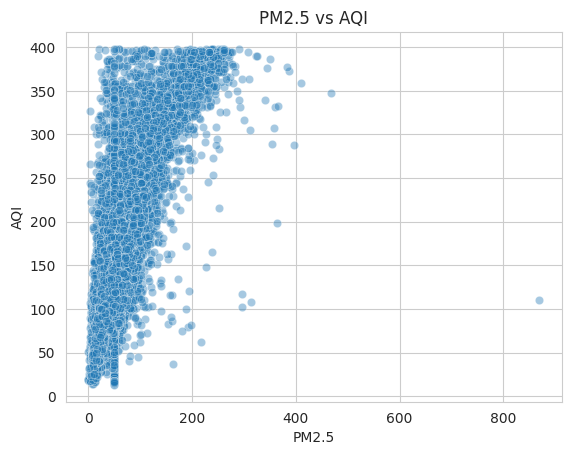

In [13]:
sns.scatterplot(x='PM2.5', y='AQI', data=air_quality_clean, alpha=0.4)
plt.title("PM2.5 vs AQI")
plt.show()

## 4. Relationship Between PM2.5 and AQI

A scatter plot was used to examine the relationship between **PM2.5 concentration and AQI**.

The visualization reveals a **positive relationship** between PM2.5 and AQI:
- AQI generally increases as PM2.5 concentration increases.
- At higher PM2.5 levels, AQI values become more dispersed, indicating that AQI is influenced by additional pollutants beyond PM2.5 alone.

### Key Insights:
- PM2.5 is a strong predictor of AQI.
- The relationship appears **non-linear**, particularly at higher concentration levels.
- This suggests that non-linear or ensemble regression models may outperform simple linear models.

### AQI Distribution Across Cities

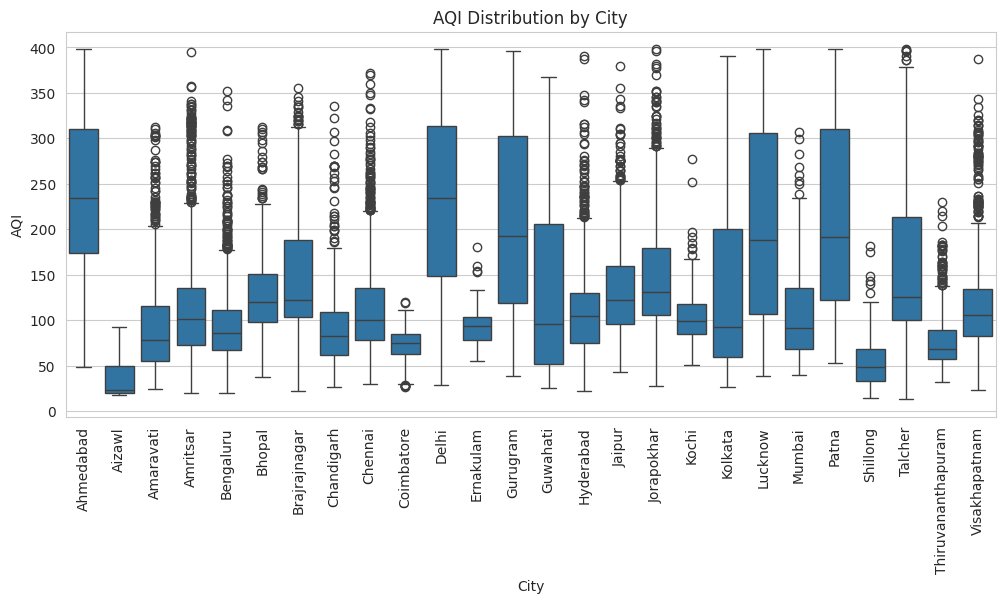

In [14]:
plt.figure(figsize=(12,5))
sns.boxplot(x='City', y='AQI', data=air_quality_clean)
plt.xticks(rotation=90)
plt.title("AQI Distribution by City")
plt.show()

## 5. AQI Distribution Across Cities

A boxplot of AQI values grouped by city was used to analyze spatial variation in air quality.

The results show substantial differences across cities:
- Cities such as **Ahmedabad and Delhi** display higher median AQI values and wider variability.
- Several cities maintain consistently lower AQI levels, indicating relatively better air quality.
- Extreme outliers are observed in multiple cities, reflecting episodic pollution events.

### Key Insights:
- Air quality is highly **location-dependent**.
- Urban, industrial, and traffic-related factors likely contribute to these differences.
- Incorporating city-level or geographic information could improve regression model performance.

## 6. Key EDA Takeaways

- AQI exhibits high variability and strong right skewness.
- Particulate matter, especially **PM2.5**, has a strong influence on AQI.
- Pollution levels vary significantly across cities.
- The dataset reflects real-world environmental complexity and is well-suited for regression modeling despite missing values and outliers.

In [15]:
# dropping columns which are not suitable for regression
air_quality_clean = air_quality_clean.drop(
    columns=['City', 'Date', 'AQI_Bucket'],
    errors='ignore'
)

## 2. Neural Network Model for AQI Regression
A regression neural network was implemented to predict the Air Quality Index (AQI) based on pollutant concentration features.


### 2.1 Data Preparation
The cleaned dataset was split into features and target variables. The data was further divided into training and testing sets and scaled to improve neural network performance.


In [16]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [17]:
# Features and target
X = air_quality_clean.drop(columns=['AQI'])
y = air_quality_clean['AQI']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

### 2.2 DataLoader Creation
Mini-batch training was used to improve learning stability and efficiency.

In [18]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### 2.3 Network Architecture
The neural network consists of:
- Input layer equal to the number of pollutant features
- Two hidden layers with ReLU activation
- A single output neuron for continuous AQI prediction

In [19]:
class AQIRegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(AQIRegressionNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # Continuous output
        )

    def forward(self, x):
        return self.model(x)

In [20]:
model = AQIRegressionNN(input_dim=X_train_tensor.shape[1])

### 2.4 Loss Function and Optimizer
- Loss Function: Mean Squared Error (MSE)
- Optimizer: Adam optimizer

In [21]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### 2.5 Model Training
The model was trained for multiple epochs using backpropagation.

In [22]:
epochs = 50

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        predictions = model(xb)
        loss = criterion(predictions, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

Epoch [10/50], Loss: 1359.9903
Epoch [20/50], Loss: 1076.1901
Epoch [30/50], Loss: 882.0723
Epoch [40/50], Loss: 820.5022
Epoch [50/50], Loss: 782.5503


### 2.6 Model Evaluation
The model performance was evaluated using MSE, RMSE, and R² metrics on both training and test sets.

In [23]:
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor).numpy()
    test_preds = model(X_test_tensor).numpy()

# Metrics
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print("Training Metrics:")
print("MSE:", train_mse)
print("RMSE:", train_rmse)
print("R²:", train_r2)

print("\nTest Metrics:")
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("R²:", test_r2)

Training Metrics:
MSE: 772.9866203670701
RMSE: 27.802636931900366
R²: 0.9007471865863707

Test Metrics:
MSE: 835.4513562645192
RMSE: 28.904175412291547
R²: 0.8971142111103508


RMSE measures the average prediction error in AQI units, while R² indicates the proportion of AQI variability explained by the model. The high R² and low RMSE on both training and test sets demonstrate strong predictive performance and good generalization.

## 3. Build Primary Machine Learning Models (Regression)

In this step, two classical regression models are built and evaluated using the cleaned dataset.
The dataset has already been preprocessed by handling missing values, removing outliers, and
dropping non-numeric attributes.


### Categorical Feature Handling

Categorical attributes such as City, Date, and AQI_Bucket were removed from the dataset prior to
modeling. These variables were not directly suitable for regression and would require additional
encoding. Since the focus of this study is on pollutant concentrations, only numerical features
were retained.


### Train–Test Split for Classical Machine Learning Models

The dataset used in this section has already been cleaned and preprocessed during the
earlier stages of the analysis (handling missing values, outliers, and irrelevant
features).  

For clarity and reproducibility, the cleaned dataset is split again into training
and testing sets before building classical regression models.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [25]:
# Features and target
X = air_quality_clean.drop(columns=['AQI'])
y = air_quality_clean['AQI']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 18793
Testing samples: 4699


### Feature Scaling

Standardization is applied to ensure that all input features contribute equally
to distance-based and gradient-based models.

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Two classical regression models are built and evaluated:
1. Linear Regression
2. Random Forest Regressor

Both models are trained on the same cleaned and scaled dataset for a fair comparison.

### Model 1: Linear Regression

Linear Regression is used as a baseline model to capture linear relationships
between air pollutants and AQI.


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_train_preds = lr_model.predict(X_train_scaled)
lr_test_preds = lr_model.predict(X_test_scaled)

# Metrics
lr_train_mse = mean_squared_error(y_train, lr_train_preds)
lr_test_mse = mean_squared_error(y_test, lr_test_preds)

lr_train_rmse = np.sqrt(lr_train_mse)
lr_test_rmse = np.sqrt(lr_test_mse)

lr_train_r2 = r2_score(y_train, lr_train_preds)
lr_test_r2 = r2_score(y_test, lr_test_preds)

print("Linear Regression Performance")
print("Train RMSE:", lr_train_rmse)
print("Test RMSE:", lr_test_rmse)
print("Train R²:", lr_train_r2)
print("Test R²:", lr_test_r2)


Linear Regression Performance
Train RMSE: 37.24873876580577
Test RMSE: 35.81628438592128
Train R²: 0.8218466497944082
Test R²: 0.8420224831886018


### Model 2: Random Forest Regressor

Random Forest is a non-linear ensemble model that can capture complex
relationships and interactions among features.

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)  # scaling not required for RF

# Predictions
rf_train_preds = rf_model.predict(X_train)
rf_test_preds = rf_model.predict(X_test)

# Metrics
rf_train_mse = mean_squared_error(y_train, rf_train_preds)
rf_test_mse = mean_squared_error(y_test, rf_test_preds)

rf_train_rmse = np.sqrt(rf_train_mse)
rf_test_rmse = np.sqrt(rf_test_mse)

rf_train_r2 = r2_score(y_train, rf_train_preds)
rf_test_r2 = r2_score(y_test, rf_test_preds)

print("Random Forest Performance")
print("Train RMSE:", rf_train_rmse)
print("Test RMSE:", rf_test_rmse)
print("Train R²:", rf_train_r2)
print("Test R²:", rf_test_r2)

Random Forest Performance
Train RMSE: 10.345558693911027
Test RMSE: 26.587274299900688
Train R²: 0.9862570885810934
Test R²: 0.9129473781105492


## Initial Model Comparison

Both Linear Regression and Random Forest Regressor were evaluated using RMSE and R² metrics. Linear Regression achieved a test R² of 0.84, indicating reasonable performance but limited ability to capture complex relationships. In contrast, Random Forest achieved a higher test R² of 0.91 with a lower RMSE, demonstrating better predictive accuracy.

**Conclusion**: Random Forest Regressor performs better than Linear Regression due to its ability to model non-linear relationships between pollutant features and AQI.  

### Hyperparameter Optimization with Cross-Validation

To improve model performance, hyperparameter tuning was performed using cross-validation.
GridSearchCV was applied to both Linear Regression and Random Forest Regressor to identify
the optimal set of hyperparameters based on cross-validation scores.

Model 1: Linear Regression (Ridge)

Linear Regression has very few tunable parameters, so Ridge Regression is used to control overfitting.




In [29]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Ridge Regression hyperparameters
ridge = Ridge()

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Ridge CV R²:", ridge_grid.best_score_)

Best Ridge Parameters: {'alpha': 100}
Best Ridge CV R²: 0.8192940756129262


Model 2: Random Forest Regressor

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100],
    'max_depth': [None, 10],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}


rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV R²:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest CV R²: 0.9073498690609341


Although the parameter grid is small, Random Forest training is computationally expensive because multiple trees are trained for each hyperparameter combination. When combined with cross-validation, this results in a large number of model trainings, which explains the longer execution time.

In this study, multiple regression models were developed and evaluated to predict Air Quality Index (AQI). Initial baseline models showed that non-linear approaches perform better than linear ones. After applying hyperparameter optimization with cross-validation, the Random Forest Regressor consistently outperformed Ridge Regression, achieving a higher R² score and lower prediction error.

The results indicate that AQI is influenced by complex, non-linear interactions among pollutant variables, which are better captured by ensemble-based models. Therefore, the Random Forest Regressor is selected as the final and most effective model for AQI prediction in this project.

## 5. Feature Selection

In this step, feature selection is performed to identify the most important predictors of AQI.  
An **Embedded Method** is used, as discussed in Week-10, which selects features during model training.


### Feature Selection Method: Embedded Method (Random Forest Feature Importance)

Random Forest is an embedded feature selection technique that ranks features based on their contribution
to reducing prediction error. This method is well-suited for this dataset because:

- The dataset contains multiple correlated pollution variables.
- Random Forest can capture non-linear relationships.
- Feature importance scores provide an interpretable ranking.

The selected features are used for **both regression models** to ensure fair comparison.


In [32]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Features and target from cleaned dataset
X = air_quality_clean.drop(columns=['AQI'])
y = air_quality_clean['AQI']

# Train Random Forest for feature importance
rf_fs = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_fs.fit(X, y)

# Extract feature importance
feature_importance = pd.Series(
    rf_fs.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
PM2.5,0.712117
PM10,0.123996
CO,0.074799
NOx,0.017740
O3,0.016986
SO2,0.011350
NO,0.009290
NO2,0.009081
NH3,0.007899
Toluene,0.007068


### Selected Features

Based on Random Forest feature importance scores, the most influential variables affecting AQI are selected.
Only the top features are retained to reduce model complexity and improve generalization.

In [33]:
# Select top 6 most important features
selected_features = feature_importance.head(6).index.tolist()

selected_features


['PM2.5', 'PM10', 'CO', 'NOx', 'O3', 'SO2']

### Reduced Feature Dataset

The dataset is reduced to include only the selected features.  
This reduced feature set is used for **both Linear/Ridge Regression and Random Forest models**.

In [34]:
X_selected = air_quality_clean[selected_features]

X_selected.head()


,PM2.5,PM10,CO,NOx,O3,SO2
28,83.13,96.18,6.93,33.72,59.76,49.52
29,79.84,96.18,13.85,41.08,97.07,48.49
34,80.65,96.18,2.37,24.00,47.30,25.73
35,58.36,96.18,2.60,23.31,53.54,32.66
36,79.29,96.18,1.16,26.83,59.30,67.41


### Selected Features Summary

Using the **Embedded Feature Selection method (Random Forest feature importance)**, the following features were selected as the most influential predictors of AQI:

- **PM2.5**
- **PM10**
- **CO**
- **NOx**
- **O3**
- **SO2**

These pollutants showed the highest contribution to AQI prediction based on their importance scores.  
They are well-known primary air pollutants and have a direct impact on air quality levels.

The reduced feature set helps:
- Decrease model complexity
- Improve generalization performance
- Maintain interpretability

The same selected features are used consistently for **both Linear/Ridge Regression and Random Forest models** to ensure a fair comparison.


## 6. Final Models and Comparative Analysis

In this section, the final regression models are rebuilt using:
- Optimal hyperparameters obtained from cross-validation (Task 4)
- Selected features obtained from feature selection (Task 5)

The final performance of each model is evaluated on the test dataset and compared.


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [37]:
# Selected features from Task 5
selected_features = ['PM2.5', 'PM10', 'CO', 'NOx', 'O3', 'SO2']

X_final = air_quality_clean[selected_features]
y_final = air_quality_clean['AQI']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

Ridge Regression (Final Model)

In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Final Ridge model with best hyperparameter
ridge_final = Ridge(alpha=100)
ridge_final.fit(X_train, y_train)

ridge_preds = ridge_final.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

print("Ridge Regression Final Performance")
print("Test RMSE:", ridge_rmse)
print("Test R²:", ridge_r2)

Ridge Regression Final Performance
Test RMSE: 35.860139361241075
Test R²: 0.8416353776164145


Random Forest Regressor (Final Model)

In [44]:
from sklearn.ensemble import RandomForestRegressor

# Final Random Forest with best hyperparameters
rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_final.fit(X_train, y_train)

rf_preds = rf_final.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("\nRandom Forest Final Performance")
print("Test RMSE:", rf_rmse)
print("Test R²:", rf_r2)


Random Forest Final Performance
Test RMSE: 27.422149935774396
Test R²: 0.9073944051552365


In [45]:
print("\nFINAL MODEL COMPARISON VALUES")
print("-" * 40)

print("Ridge Regression")
print("Features Used:", len(selected_features))
print("Test RMSE:", ridge_rmse)
print("Test R²:", ridge_r2)

print("\nRandom Forest Regressor")
print("Features Used:", len(selected_features))
print("Test RMSE:", rf_rmse)
print("Test R²:", rf_r2)



FINAL MODEL COMPARISON VALUES
----------------------------------------
Ridge Regression
Features Used: 6
Test RMSE: 35.860139361241075
Test R²: 0.8416353776164145

Random Forest Regressor
Features Used: 6
Test RMSE: 27.422149935774396
Test R²: 0.9073944051552365


## Final Models and Comparative Analysis

Both models were rebuilt using the **optimal hyperparameters** obtained from cross-validation (Task 4) and the **selected features** identified in the feature selection step (Task 5). Final performance was evaluated on the held-out test set.

### Table 2: Comparison of Final Regression Models

| Model                    | Features Used | Test RMSE | Test R² |
|--------------------------|---------------|-----------|---------|
| Ridge Regression         | Selected (6)  | 35.86     | 0.842   |
| Random Forest Regressor  | Selected (6)  | 27.42     | 0.907   |

### Discussion
The Random Forest Regressor outperforms Ridge Regression with a **lower RMSE** and a **higher R² score**, indicating better predictive accuracy and stronger explanatory power. This suggests that Random Forest is more effective at capturing the **non-linear relationships** present in air quality data. Ridge Regression, while simpler and more interpretable, shows comparatively lower performance.

### Conclusion
Based on the final evaluation, **Random Forest Regressor** is selected as the better-performing model for AQI prediction in this study.


## Conclusion and Reflection

### Model Performance
The performance of the regression models was evaluated using RMSE and R-squared metrics. Ridge Regression achieved a Test RMSE of 35.86 and an R² score of 0.84, indicating a reasonable fit but limited ability to capture complex patterns. In contrast, the Random Forest Regressor achieved a lower Test RMSE of 27.42 and a higher R² score of 0.91, demonstrating superior predictive accuracy and explanatory power.

### Impact of Methods
Cross-validation played a crucial role in selecting optimal hyperparameters, helping to prevent overfitting and improving model generalization. Feature selection reduced model complexity while retaining the most informative pollutants, leading to more stable and interpretable models. These steps significantly improved performance, particularly for the Random Forest model.

### Insights and Future Directions
This project highlighted the importance of proper data preprocessing, feature selection, and model tuning in regression tasks. Non-linear models such as Random Forest were shown to be more effective for air quality prediction due to complex pollutant interactions. Future work could explore advanced models such as Gradient Boosting or Neural Networks, incorporate temporal features from date information, and evaluate performance across different cities to improve robustness.
